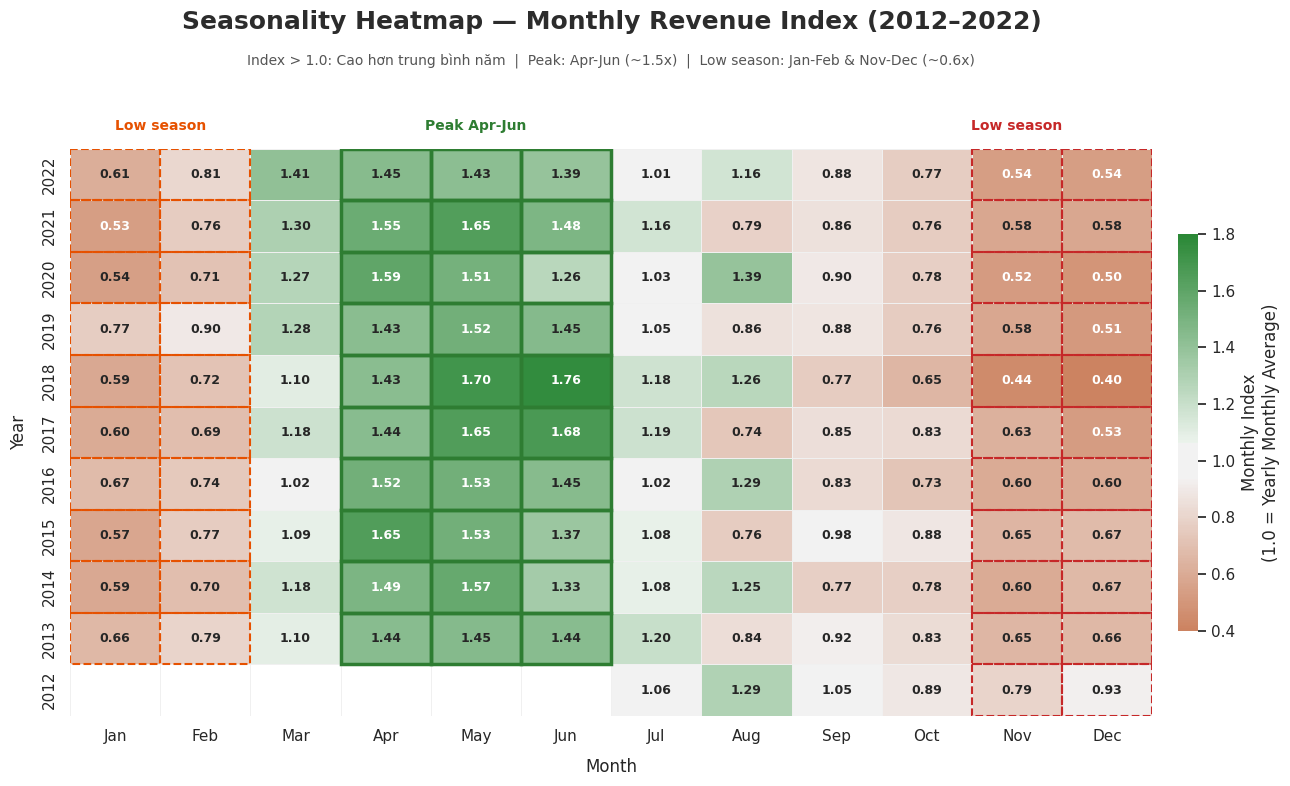

Success! Biểu đồ đã được lưu tại: d:\BountyHunter\reports\figures\chart_1b_final.png


In [26]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.ticker as mticker
# import seaborn as sns
# import os

# root_dir   = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
# output_dir = os.path.join(root_dir, "reports", "figures")
# os.makedirs(output_dir, exist_ok=True)

# MONTH_LABELS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
#                 "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# def generate_chart_1b():
#     # ── Load ──────────────────────────────────────────────────────
#     sales = pd.read_parquet(os.path.join(root_dir, "data", "processed", "sales.parquet"))

#     sales["year"]  = sales["Date"].dt.year
#     sales["month"] = sales["Date"].dt.month

#     # ── Tinh monthly index ────────────────────────────────────────
#     # monthly_revenue = tong revenue trong thang
#     monthly = (
#         sales.groupby(["year", "month"])["Revenue"]
#         .sum()
#         .reset_index(name="monthly_revenue")
#     )

#     # yearly_avg = trung binh cac thang trong nam (khong dung sum de tranh
#     # nam 2012 chi co 6 thang lam lech)
#     yearly_avg = (
#         monthly.groupby("year")["monthly_revenue"]
#         .mean()
#         .reset_index(name="yearly_avg")
#     )

#     monthly = monthly.merge(yearly_avg, on="year")
#     monthly["monthly_index"] = monthly["monthly_revenue"] / monthly["yearly_avg"]

#     # ── Pivot sang dang matrix year x month ──────────────────────
#     pivot = monthly.pivot(index="year", columns="month", values="monthly_index")
#     pivot.columns = MONTH_LABELS
#     pivot = pivot.sort_index(ascending=False)   # nam moi len tren

#     # ── Ve ────────────────────────────────────────────────────────
#     sns.set_theme(style="white", font="DejaVu Sans")

#     fig, ax = plt.subplots(figsize=(14, 7))
#     fig.patch.set_facecolor("white")

#     # custom diverging palette: cam nhat = thap, xanh la = cao
#     cmap = sns.diverging_palette(
#         h_neg=25, h_pos=130,
#         s=85, l=50,
#         sep=20, as_cmap=True
#     )

#     sns.heatmap(
#         pivot,
#         ax=ax,
#         cmap=cmap,
#         center=1.0,           # trung tam = 1.0 (bang trung binh)
#         vmin=0.4,
#         vmax=1.8,
#         annot=True,
#         fmt=".2f",
#         annot_kws={"size": 8, "weight": "bold"},
#         linewidths=0.5,
#         linecolor="#E0E0E0",
#         cbar_kws={
#             "label": "Monthly Index\n(1.0 = monthly average)",
#             "shrink": 0.8,
#             "pad": 0.02,
#         }
#     )

#     # ── Colorbar label ────────────────────────────────────────────
#     cbar = ax.collections[0].colorbar
#     cbar.ax.tick_params(labelsize=8)
#     cbar.set_label("Monthly Index\n(1.0 = monthly average)",
#                    fontsize=8.5, labelpad=10)

#     # ── Q4 highlight: box quanh cot Apr-May-Jun (peak thuc te) ───
#     n_rows = len(pivot)
#     for col_idx in [3, 4, 5]:   # Apr=3, May=4, Jun=5
#         ax.add_patch(plt.Rectangle(
#             (col_idx, 0), 1, n_rows,
#             fill=False, edgecolor="#2E7D32",
#             linewidth=2.0, zorder=3
#         ))
#     ax.text(4.5, -0.6, "Peak (Apr–Jun)",
#             ha="center", va="bottom",
#             fontsize=8.5, color="#2E7D32",
#             fontweight="bold", clip_on=False)

#     # ── Low season: box quanh Nov-Dec ─────────────────────────────
#     for col_idx in [10, 11]:    # Nov=10, Dec=11
#         ax.add_patch(plt.Rectangle(
#             (col_idx, 0), 1, n_rows,
#             fill=False, edgecolor="#C62828",
#             linewidth=1.5, linestyle="--",
#             zorder=3
#         ))
#     ax.text(10.5, -0.6, "Low season",
#             ha="center", va="bottom",
#             fontsize=8.5, color="#C62828",
#             fontweight="bold", clip_on=False)

#     # ── Tet highlight: box quanh Jan va Feb ───────────────────────
#     for col_idx in [0, 1]:
#         ax.add_patch(plt.Rectangle(
#             (col_idx, 0), 1, n_rows,
#             fill=False, edgecolor="#E65100",
#             linewidth=1.5, linestyle="--",
#             zorder=3
#         ))

#     ax.text(1.0, -0.6, "low season",
#             ha="center", va="bottom",
#             fontsize=8.5, color="#E65100",
#             fontweight="bold", clip_on=False)

#     # ── Annotation: 2019-2020 anomaly ─────────────────────────────
#     # 2019 nam o row nao trong pivot (sort descending)
#     years_list = list(pivot.index)
#     if 2019 in years_list:
#         row_2019 = years_list.index(2019)
#         ax.annotate(
#             "2019: Structural\nbreak",
#             xy=(12, row_2019 + 0.5),
#             xytext=(12.3, row_2019 + 0.5),
#             fontsize=7.5, color="#C62828",
#             va="center", clip_on=False,
#             arrowprops=dict(arrowstyle="->",
#                             color="#C62828", lw=0.8)
#         )

#     # ── Labels ────────────────────────────────────────────────────
#     ax.set_xlabel("Tháng", fontsize=11, labelpad=10, color="#2C2C2C")
#     ax.set_ylabel("Năm",   fontsize=11, labelpad=10, color="#2C2C2C")
#     ax.tick_params(axis="x", labelsize=9, rotation=0)
#     ax.tick_params(axis="y", labelsize=9, rotation=0)

#     # ── Title ─────────────────────────────────────────────────────
#     fig.suptitle(
#         "Seasonality Heatmap — Monthly Revenue Index (2012–2022)",
#         fontsize=13, fontweight="bold",
#         color="#2C2C2C", y=1.02
#     )
#     ax.set_title(
#         "Index > 1.0: tháng cao hơn trung bình năm  |  "
#         "Peak: Apr–Jun (1.4–1.6×)  |  "
#         "Low season: Nov–Dec (~0.6×)",
#         fontsize=9, color="#6B6B6B", pad=10
#     )

#     # ── Save ──────────────────────────────────────────────────────
#     plt.tight_layout()
#     save_path = os.path.join(output_dir, "chart_1b.png")
#     plt.savefig(save_path, dpi=150, bbox_inches="tight",
#                 facecolor="white")
#     plt.show()
#     print(f"Saved: {save_path}")

# generate_chart_1b()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

# ── SETUP PATHS ──────────────────────────────────────────────────
root_dir   = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
output_dir = os.path.join(root_dir, "reports", "figures")
os.makedirs(output_dir, exist_ok=True)

MONTH_LABELS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

def generate_chart_1b_final():
    # ── 1. LOAD & PREPROCESS ──────────────────────────────────────
    # Sử dụng file sales.parquet từ thư mục processed
    sales_path = os.path.join(root_dir, "data", "processed", "sales.parquet")
    if not os.path.exists(sales_path):
        print(f"Error: Không tìm thấy file tại {sales_path}")
        return
        
    sales = pd.read_parquet(sales_path)
    sales["year"]  = sales["Date"].dt.year
    sales["month"] = sales["Date"].dt.month

    # Tính Monthly Revenue
    monthly = (
        sales.groupby(["year", "month"])["Revenue"]
        .sum()
        .reset_index(name="monthly_revenue")
    )

    # Tính Yearly Average (Trung bình các tháng hiện có trong năm)
    yearly_avg = (
        monthly.groupby("year")["monthly_revenue"]
        .mean()
        .reset_index(name="yearly_avg")
    )

    # Tính Monthly Index = Revenue tháng đó / Trung bình tháng của năm đó
    monthly = monthly.merge(yearly_avg, on="year")
    monthly["monthly_index"] = monthly["monthly_revenue"] / monthly["yearly_avg"]

    # Pivot sang dạng matrix Year x Month
    pivot = monthly.pivot(index="year", columns="month", values="monthly_index")
    pivot.columns = MONTH_LABELS
    pivot = pivot.sort_index(ascending=False) # Năm mới nhất nằm trên cùng

    # ── 2. TÍNH TOÁN CHỈ SỐ ĐỘNG (Bỏ qua NaN bằng nanmean) ────────
    peak_months = ["Apr", "May", "Jun"]
    low_months  = ["Jan", "Feb", "Nov", "Dec"]
    
    peak_avg = np.nanmean(pivot[peak_months].values)
    low_avg  = np.nanmean(pivot[low_months].values)

    # ── 3. CẤU HÌNH BIỂU ĐỒ ───────────────────────────────────────
    sns.set_theme(style="white", font="DejaVu Sans")
    fig, ax = plt.subplots(figsize=(14, 8))
    fig.patch.set_facecolor("white")

    # Custom color palette: Cam (thấp) -> Trắng (1.0) -> Xanh lá (cao)
    cmap = sns.diverging_palette(h_neg=25, h_pos=130, s=85, l=50, sep=20, as_cmap=True)

    # Vẽ Heatmap
    sns.heatmap(
        pivot,
        ax=ax,
        cmap=cmap,
        center=1.0,
        vmin=0.4,
        vmax=1.8,
        annot=True,
        fmt=".2f",
        annot_kws={"size": 9, "weight": "bold"},
        linewidths=0.7,
        linecolor="#F0F0F0",
        cbar_kws={
            "label": "Monthly Index\n(1.0 = Yearly Monthly Average)",
            "shrink": 0.7,
            "pad": 0.02,
        }
    )

    # ── 4. LOGIC VẼ HIGHLIGHT TỪNG Ô (CHỈ VẼ NẾU CÓ DATA) ──────────
    def draw_cell_highlights(target_months, color, linestyle="-", linewidth=2.0):
        """Duyệt từng ô, nếu không phải NaN thì mới vẽ khung viền"""
        for month in target_months:
            col_idx = list(pivot.columns).index(month)
            for row_idx in range(len(pivot)):
                val = pivot.iloc[row_idx, col_idx]
                if not np.isnan(val): # Kiểm tra ô có dữ liệu hay không
                    ax.add_patch(plt.Rectangle(
                        (col_idx, row_idx), 1, 1, 
                        fill=False, edgecolor=color, 
                        linewidth=linewidth, linestyle=linestyle, zorder=5
                    ))

    # Vẽ Peak (Apr-Jun) - Khung xanh liền mạch
    draw_cell_highlights(peak_months, "#2E7D32", linewidth=2.5)
    
    # Vẽ Low Season (Jan-Feb) - Khung cam nét đứt
    draw_cell_highlights(["Jan", "Feb"], "#E65100", linestyle="--", linewidth=1.5)
    
    # Vẽ Low Season (Nov-Dec) - Khung đỏ nét đứt
    draw_cell_highlights(["Nov", "Dec"], "#C62828", linestyle="--", linewidth=1.5)

    # ── 5. ANNOTATIONS & LABELS ───────────────────────────────────
    # Labels cho các vùng highlight
    ax.text(4.5, -0.3, f"Peak {peak_months[0]}-{peak_months[-1]}", ha="center", va="bottom", 
            fontsize=10, color="#2E7D32", fontweight="bold", clip_on=False)
    
    ax.text(1.0, -0.3, "Low season", ha="center", va="bottom", 
            fontsize=10, color="#E65100", fontweight="bold", clip_on=False)
            
    ax.text(10.5, -0.3, "Low season", ha="center", va="bottom", 
            fontsize=10, color="#C62828", fontweight="bold", clip_on=False)

    # # Annotation cho điểm gãy 2019
    # years_list = list(pivot.index)
    # if 2019 in years_list:
    #     row_2019 = years_list.index(2019)
    #     ax.annotate(
    #         "2019: Structural Break\n(Revenue Dropped)",
    #         xy=(12, row_2019 + 0.5),
    #         xytext=(12.5, row_2019 + 0.5),
    #         fontsize=9, color="#C62828", fontweight="bold",
    #         va="center", clip_on=False,
    #         arrowprops=dict(arrowstyle="->", color="#C62828", lw=1.5)
    #     )

    # ── 6. TITLES ─────────────────────────────────────────────────
    fig.suptitle(
        "Seasonality Heatmap — Monthly Revenue Index (2012–2022)",
        fontsize=18, fontweight="bold", color="#2C2C2C", x=0.443, y=0.98
    )
    
    dynamic_subtitle = (
        "Index > 1.0: Cao hơn trung bình năm  |  "
        f"Peak: {peak_months[0]}-{peak_months[-1]} (~{peak_avg:.1f}x)  |  "
        f"Low season: Jan-Feb & Nov-Dec (~{low_avg:.1f}x)"
    )
    
    ax.set_title(dynamic_subtitle, fontsize=10, color="#555555", pad=60, x=0.5)
    ax.set_xlabel("Month", fontsize=12, labelpad=10)
    ax.set_ylabel("Year", fontsize=12, labelpad=10)

    # ── 7. SAVE & SHOW ────────────────────────────────────────────
    plt.tight_layout()
    save_path = os.path.join(output_dir, "chart_1b_final.png")
    plt.savefig(save_path, dpi=200, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Success! Biểu đồ đã được lưu tại: {save_path}")

# Chạy hàm
generate_chart_1b_final()
